# Supp. Fig. 21 — Kegg Ecm Receptor Interaction Pathway Score & Neighborhood Enrichment (MASL tissue)

**Purpose:** Score hepatocytes for the `KEGG_ECM_RECEPTOR_INTERACTION` gene signature (leading-edge
genes from a GSEA comparison), label the top 1% highest-scoring hepatocytes
as a distinct pseudo-cell-type, then run Squidpy neighborhood enrichment on
the full (all-cell-type) spatial object to see which cell types these
high-scoring hepatocytes tend to neighbor.

**Gene signature source:** leading-edge genes for `KEGG_ECM_RECEPTOR_INTERACTION` from the
`MASH_vs_Control` GSEA hepatocyte comparison.

**Tissue sample scored:** `HL230324_filt` (MASL condition).

**Pipeline:**
1. Load GSEA results and pull the leading-edge gene list for `KEGG_ECM_RECEPTOR_INTERACTION`.
2. Load the sample's merged spatial object and score cells for the gene set
   (`sc.tl.score_genes`).
3. Compute the 99th-percentile score cutoff and plot it spatially.
4. Label hepatocytes at/above that cutoff as
   `Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells`; write out the hepatocyte-only object
   with this new label.
5. Map that label back onto the full (all-cell-type) spatial object.
6. Run Squidpy `spatial_neighbors` + `nhood_enrichment` on the full object,
   grouped by the updated cell-type column.
7. Plot/save the enrichment matrix, and extract+save just the rows for the
   two hepatocyte categories (background vs. top-1%) as a small heatmap and
   a tab-separated table (prefixed `MASL_`), to make it
   easy to compare across tissues/conditions in a combined figure.

**Cleanup notes (this pass):** removed a large amount of leftover
exploratory/duplicate code that accumulated while developing this notebook:
redundant re-imports scattered through the file (consolidated into one cell
at the top), an unused multi-sample-loop scaffold (`adata_paths`, `glob`,
`Path`) that was never actually used (the notebook operates on one
already-loaded `adata`), several bare variable-display cells left over from
interactive debugging (some of which even errored, since they referenced
variables not yet defined at that point in the notebook), and duplicate
reruns of the same percentile-cutoff / neighborhood-enrichment-heatmap code.
Only one save call for each output file (score map, enrichment matrix,
hepatocyte-subset heatmap/table) has been kept, using the copy that actually
matches its final saved filename. No analysis logic that produces saved
outputs was changed.

## Setup

In [1]:
import os
import datetime

import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead

## Load GSEA results and select the gene set to score

In [2]:
gsea_df = pd.read_csv('/tscc/lustre/ddn/scratch/welison/Liver_Share/result.depot/250805_WE_fGSEA_RNA_Reupload/GSEA.CP_Hepatocytes_MASH_vs_Control.go.kegg.reactome.hallmark.nothresh.res', sep = "\t")

In [3]:
gsea_df.head()

,pathway,pval,padj,log2err,ES,NES,size,leadingEdge
0,GOBP_2FE_2S_CLUSTER_ASSEMBLY,0.454231,0.692221,0.076477,0.410849,1.017937,11,FXN|NDUFAB1|ISCU|GLRX3|FDX2
1,GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS,0.743902,0.881390,0.068957,-0.262973,-0.803877,17,AADAT|IDH1|L2HGDH
2,GOBP_3_PHOSPHOADENOSINE_5_PHOSPHOSULFATE_METAB...,0.588670,0.785927,0.081527,-0.305605,-0.908216,16,PAPSS1|ENPP1|TPST1
3,GOBP_3_UTR_MEDIATED_MRNA_DESTABILIZATION,0.050676,0.218428,0.261664,0.540896,1.490455,17,DND1|PLEKHN1|TRIM71|ZC3H12D|RBM24|RC3H1|UPF1|K...
4,GOBP_3_UTR_MEDIATED_MRNA_STABILIZATION,0.393740,0.646972,0.081527,0.363504,1.058504,20,MAPK14|TENT4A|HNRNPA0|RBM24|ELAVL4|BOLL|MAPKAP...


In [4]:
gene_sets = [
        "KEGG_ECM_RECEPTOR_INTERACTION"
]

## Load the sample's spatial object

In [5]:
sample_nm = 'HL230324_filt'

In [6]:
inp_dir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/tangram/deep_seq_heps_alldonors_ds10k_ref/'


In [7]:
sp_file_path = os.path.join(inp_dir, sample_nm, 'merge/Post_sp_ct_proj_comb_outer.h5ad')
adata = sc.read_h5ad(sp_file_path)
print(adata)

AnnData object with n_obs × n_vars = 197933 × 17687
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_cropped', 'tangram_ct_pred'


In [8]:
adata.obs['celltype_proj'].value_counts()

celltype_proj
Hepatocytes.Zone3    86504
Hepatocytes.Zone2    58723
Hepatocytes.Zone1    52706
Name: count, dtype: int64

In [16]:
adata.obs['pred_cell_types'].value_counts()

pred_cell_types
Hepatocytes    197933
Name: count, dtype: int64

## Score cells for the gene set and preview spatially

Uses the leading-edge genes for each pathway in `gene_sets` (here just one, but written to loop over a list).

2025-08-30 17:49:53.063684


/scratch/cmiciano/job_7146120/ipykernel_4130636/3852753937.py:54: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,


2025-08-30 17:50:04.639943


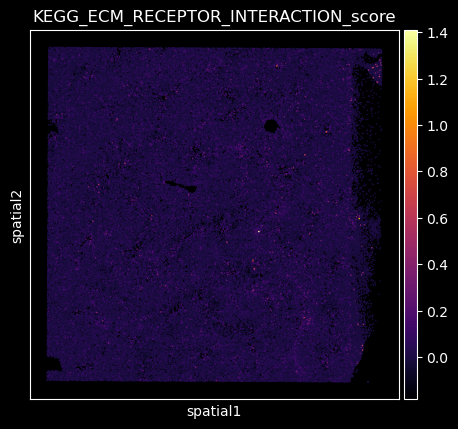

In [9]:
# Score all pathways in gene_sets, even if not GSEA-significant, so scores are
# comparable across pathways/samples.
available_pathways = set(gsea_df['pathway'])

print(datetime.datetime.now())

for pw_name in gene_sets:  # make sure the pathway plotted is one used in the combined heatmap
    if pw_name not in available_pathways:
        print(f"  -> Skipped {pw_name}: not in filtered GSEA")
        continue

    row = gsea_df[gsea_df['pathway'] == pw_name]
    leading_edge_series = row['leadingEdge']
    if leading_edge_series.isna().any():
        print(f"  -> Skipped {pw_name}: missing leadingEdge")
        continue

    pw_genes = leading_edge_series.iloc[0].split('|')
    pw_genes = [gene.lower() for gene in pw_genes]

    # Score genes
    sc.tl.score_genes(adata, pw_genes, score_name=f"{pw_name}_score")

    # Quick spatial preview of the raw score
    plt.style.use('dark_background')
    sc.pl.spatial(
        adata,
        color=[f"{pw_name}_score"],
        cmap='inferno',
        size=4,
        img_key=None,
        show=False,
    )

print(datetime.datetime.now())


### Custom white-to-red colormap

Used below to highlight the top-scoring cells (white -> light red up to the 90th percentile, then solid red for the top 10%).

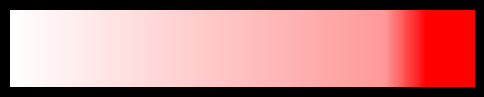

In [10]:
# White -> Red, saturating quickly so the top values stand out
custom_white_red = mcolors.LinearSegmentedColormap.from_list(
    "white_red_toplock",
    [
        (0.0, "#ffffff"),  # White
        (0.9, "#ff9999"),  # Light-medium red at 90%
        (1.0, "#ff0000"),  # Full red for top values
    ]
)

# Optional: preview the colormap
percentile_cutoff = 0.9
values = np.linspace(0, 1, 256)
norm_values = np.clip(values, 0, percentile_cutoff) / percentile_cutoff
norm_values[norm_values > 1] = 1

plt.figure(figsize=(6, 1))
plt.imshow(norm_values.reshape(1, -1), aspect="auto", cmap=custom_white_red)
plt.axis("off")
plt.show()


In [11]:
plt.rcdefaults()  # reset style after the dark_background plots above


## Compute the top-1% score cutoff and plot/save it spatially

/scratch/cmiciano/job_7146120/ipykernel_4130636/1028507195.py:35: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


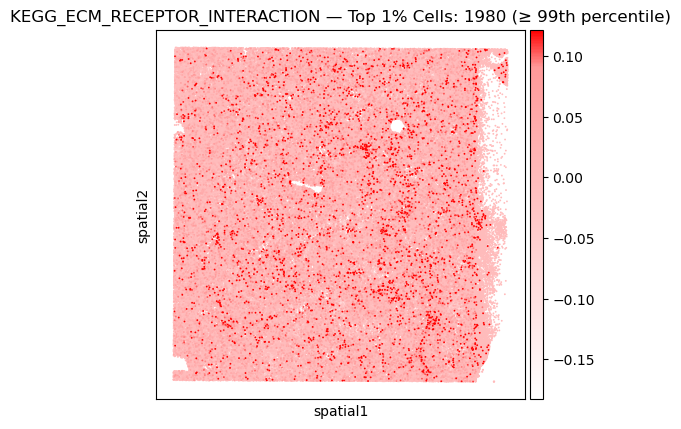

In [12]:
# Top 1% cutoff (written as a loop originally to support scanning multiple
# percentiles; only the 99th percentile is used here)
p = 99

scores = adata.obs[f"{pw_name}_score"].dropna()
cutoff = np.percentile(scores, p)
num_top_cells = (scores >= cutoff).sum()
plot_title = f"{pw_name} \u2014 Top {100 - p}% Cells: {num_top_cells} (>= {p}th percentile)"

sc.pl.spatial(
    adata,
    color=f"{pw_name}_score",
    size=5,
    img_key=None,
    title=plot_title,
    cmap=custom_white_red,
    vmax=cutoff,
    show=False,
)


In [65]:
sc.pl.spatial(
    adata,
    color=f"{pw_name}_score",
    size=5,
    img_key=None,
    title=plot_title,
    cmap=custom_white_red,
    vmax=cutoff,
    vmin=0,
    show=False,
)
plt.savefig(f"{outp}{pw_name}_score_red_white_{p}th_percentile_vmin0.pdf", bbox_inches="tight")
plt.close()


/scratch/cmiciano/job_7116984/ipykernel_1711645/143510386.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


## Label the top-1% hepatocytes and write out the hepatocyte object

In [19]:
cutoff = np.percentile(scores, p)
num_top_cells = (scores >= cutoff).sum()

# New column flagging cells at/above the top-1% score cutoff
colname = f"{pw_name}_top_{100 - p}pct"
adata.obs[colname] = np.where(
    adata.obs[f"{pw_name}_score"] >= cutoff,
    "High_score",
    "Low_score",
)


In [20]:
adata.obs['KEGG_ECM_RECEPTOR_INTERACTION_top_1pct'].value_counts()

KEGG_ECM_RECEPTOR_INTERACTION_top_1pct
Low_score     195953
High_score      1980
Name: count, dtype: int64

In [23]:
# Relabel hepatocytes in the top 1% for this pathway score as a distinct pseudo-cell-type
adata.obs['celltype_proj_heps_top1pct'] = adata.obs.apply(
    lambda row: 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells' if row['KEGG_ECM_RECEPTOR_INTERACTION_top_1pct'] == 'High_score' else row['pred_cell_types'],
    axis=1,
)


In [24]:
adata.obs['celltype_proj_heps_top1pct'].value_counts()

celltype_proj_heps_top1pct
Hepatocytes                                                 195953
Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells      1980
Name: count, dtype: int64

In [25]:
# Per-sample output directory for this pathway/condition
outp = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_mash/HL230324_filt/'
os.makedirs(outp, exist_ok=True)


In [26]:
adata.write_h5ad(f"{outp}adata_heps_top1pct_label_broad_ct.h5ad")

In [27]:
adata_heps = sc.read_h5ad(f"{outp}adata_heps_top1pct_label_broad_ct.h5ad")

## Map the new hepatocyte label back onto the full (all-cell-type) object

In [28]:
adata_all_ct = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL230324_filt/adata_0.5_tangram_filt.h5ad')

In [29]:
full_adata = adata_all_ct.copy()

In [30]:
full_adata.obs['celltype_proj'].value_counts()

celltype_proj
Hepatocytes      197504
Endothelial       20205
Myeloid           15252
Cholangiocyte     11642
HSC               11177
T_NK               7646
B                  6865
Name: count, dtype: int64

In [31]:
full_adata.obs['pred_cell_types'].value_counts()

pred_cell_types
Hepatocytes      197933
Endothelial       20065
Myeloid           15352
HSC               11324
Cholangiocyte     11078
T_NK               7843
B                  6696
Name: count, dtype: int64

In [32]:
# Map the hepatocyte-only top-1% label back onto the matching cells in the full object,
# and fill everything else (non-hepatocytes) with their existing predicted cell type.
hepatocyte_mapping = adata_heps.obs['celltype_proj_heps_top1pct'].to_dict()
full_adata.obs['celltype_proj_heps_top1pct'] = full_adata.obs.index.map(hepatocyte_mapping)

full_adata.obs['celltype_proj_heps_top1pct'] = full_adata.obs['celltype_proj_heps_top1pct'].astype(str)
full_adata.obs['pred_cell_types'] = full_adata.obs['pred_cell_types'].astype(str)
full_adata.obs['celltype_proj_heps_top1pct'] = full_adata.obs['celltype_proj_heps_top1pct'].fillna(
    full_adata.obs['pred_cell_types']
)
full_adata.obs['celltype_proj_heps_top1pct'] = full_adata.obs['celltype_proj_heps_top1pct'].astype("category")

print(full_adata.obs[['pred_cell_types', 'celltype_proj_heps_top1pct']].head())


       pred_cell_types celltype_proj_heps_top1pct
126811     Hepatocytes                Hepatocytes
126812     Hepatocytes                Hepatocytes
126813            T_NK                        nan
126814     Endothelial                        nan
126816     Hepatocytes                Hepatocytes


/scratch/cmiciano/job_7146120/ipykernel_4130636/1857340242.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_adata.obs['celltype_proj_heps_top1pct'].fillna(full_adata.obs['pred_cell_types'], inplace=True)


In [34]:
full_adata.obs['celltype_proj_heps_top1pct'].value_counts()

celltype_proj_heps_top1pct
Hepatocytes                                                 195953
Endothelial                                                  20065
Myeloid                                                      15352
HSC                                                          11324
Cholangiocyte                                                11078
T_NK                                                          7843
B                                                             6696
Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells      1980
Name: count, dtype: int64

In [35]:
full_adata.obs['celltype_proj_allct_top1pct'] = full_adata.obs['celltype_proj_heps_top1pct']

In [37]:
full_adata.write_h5ad(f"{outp}adata_all_ct_heps_top1pct_label_broad_ct.h5ad")

## Neighborhood enrichment (Squidpy) on the full object

2025-08-30 17:51:08.378126
2025-08-30 17:51:21.095998


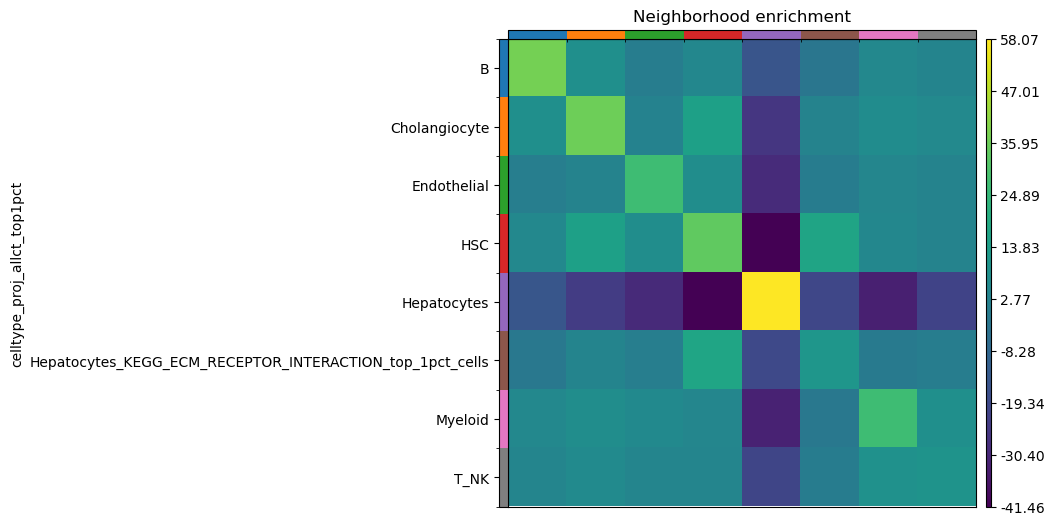

In [39]:
print(datetime.datetime.now())

sq.gr.spatial_neighbors(full_adata)
sq.gr.nhood_enrichment(full_adata, cluster_key="celltype_proj_allct_top1pct", show_progress_bar=False)
sq.pl.nhood_enrichment(full_adata, cluster_key="celltype_proj_allct_top1pct")

print(datetime.datetime.now())


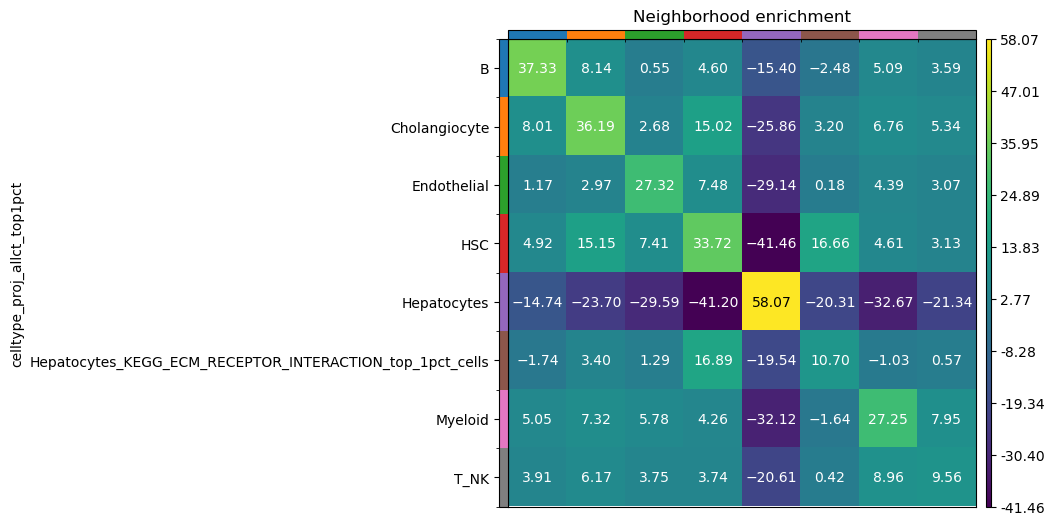

In [41]:
sq.pl.nhood_enrichment(full_adata, cluster_key="celltype_proj_allct_top1pct", annotate=True)
plt.savefig(outp + 'enrich_mat_broad_ct.pdf', bbox_inches='tight')


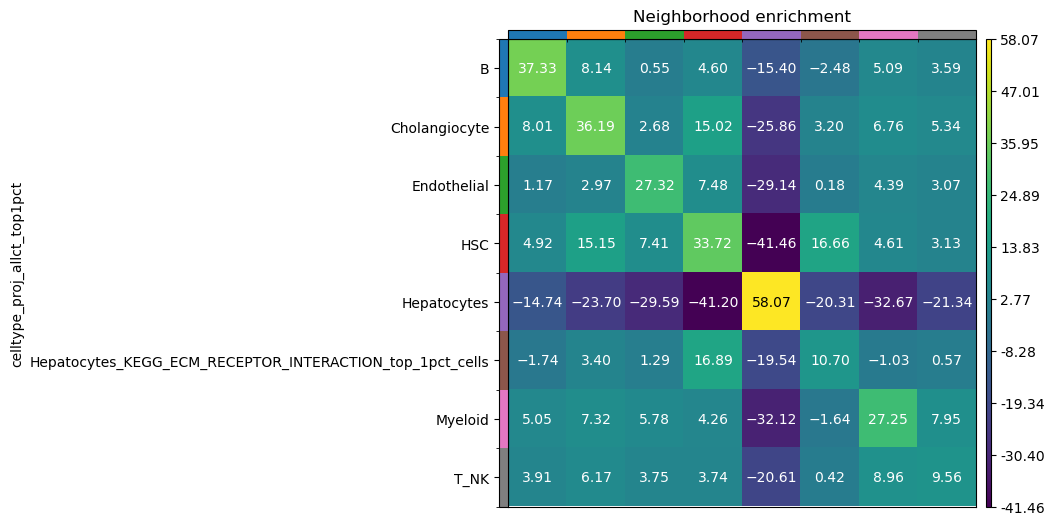

In [42]:
# NOTE: kept as originally written; this saves the same annotated plot as the
# cell above under a second filename (no un-annotated variant is produced).
sq.pl.nhood_enrichment(full_adata, cluster_key="celltype_proj_allct_top1pct", annotate=True)
plt.savefig(outp + 'enrich_mat_broad_ct_anno.pdf', bbox_inches='tight')


## Extract the hepatocyte-only rows and save a small comparison heatmap/table

In [45]:
ct_sort = full_adata.obs["celltype_proj_allct_top1pct"].unique().tolist()

In [47]:
ct_sort.sort()

In [48]:
ct_sort

['B',
 'Cholangiocyte',
 'Endothelial',
 'HSC',
 'Hepatocytes',
 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells',
 'Myeloid',
 'T_NK']

In [49]:
heps_labels = ['Hepatocytes', 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells']


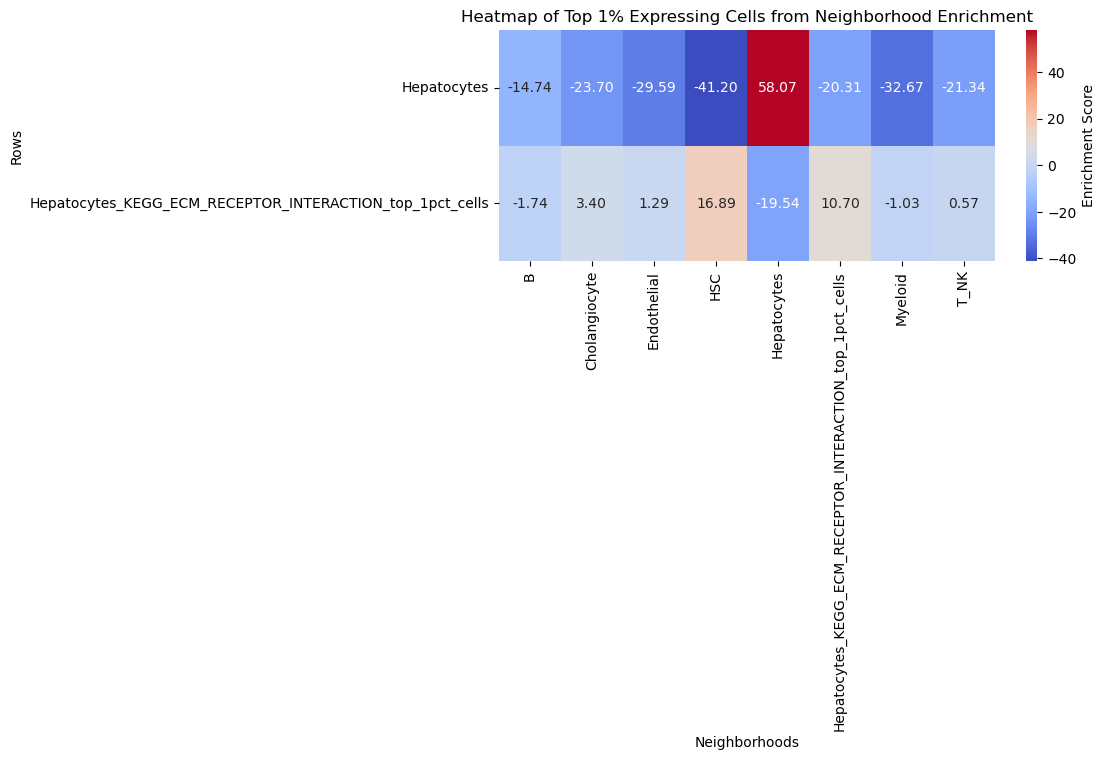

In [51]:
# Pull the z-score neighborhood-enrichment matrix and isolate just the two
# hepatocyte rows (background hepatocytes vs. top-1% pathway-score hepatocytes)
enrichment_data = full_adata.uns['celltype_proj_allct_top1pct_nhood_enrichment']['zscore']
enrichment_df = pd.DataFrame(enrichment_data)

rows_to_plot = enrichment_df.iloc[4:6]  # rows corresponding to heps_labels, given ct_sort's order
col_indices = list(range(enrichment_df.shape[1]))
rows_to_plot_values = rows_to_plot.values

plt.figure(figsize=(8, 3))
sns.heatmap(
    rows_to_plot_values, cmap='coolwarm', fmt='.2f', annot=True,
    xticklabels=[ct_sort[i] for i in col_indices], yticklabels=heps_labels,
    cbar_kws={'label': 'Enrichment Score'},
)
plt.title("Heatmap of Top 1% Expressing Cells from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
plt.xticks(rotation=90)
plt.savefig(outp + 'enrich_mat_broad_ct_kegg_red_blue_only_all_heps.pdf', bbox_inches='tight')


In [52]:
col_names = [ct_sort[i] for i in col_indices]
col_names 

['B',
 'Cholangiocyte',
 'Endothelial',
 'HSC',
 'Hepatocytes',
 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells',
 'Myeloid',
 'T_NK']

In [53]:
row_names = heps_labels
row_names

['Hepatocytes', 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells']

In [58]:
cond_row_names = ["MASL_" + x for x in row_names]
cond_row_names


['MASL_Hepatocytes',
 'MASL_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells']

In [63]:
df = pd.DataFrame(
    rows_to_plot_values,
    index=cond_row_names,
    columns=col_names,
)
df.to_csv(f"{outp}kegg_ecm_receptor_interaction_neighbor.txt", sep="\t", index=True)
df


,B,Cholangiocyte,Endothelial,HSC,Hepatocytes,Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,Myeloid,T_NK
MASL_Hepatocytes,-14.737366,-23.699141,-29.588153,-41.198469,58.068795,-20.307373,-32.674141,-21.341247
MASL_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,-1.738342,3.401604,1.291483,16.889827,-19.541908,10.699425,-1.027013,0.573780
